# МИДТЕРМ 2: Fashion-MNIST сурет классификациясы

**Тақырып:** Neural Network / Deep Learning project  
**Мақсат:** Fashion-MNIST dataset бойынша киім суреттерін 10 класқа классификациялау.

Бұл notebook ішінде:

- dataset жүктеледі және сипатталады;
- EDA жасалады;
- preprocessing орындалады;
- 2 нейрондық желі оқытылады: MLP және CNN;
- модельдер accuracy, loss, confusion matrix және classification report арқылы салыстырылады.

## Dataset туралы

- **Dataset:** Fashion-MNIST
- **Source:** Zalando Research
- **Official GitHub:** https://github.com/zalandoresearch/fashion-mnist
- **Kaggle:** https://www.kaggle.com/datasets/zalando-research/fashionmnist
- **Жүктеу тәсілі:** `keras.datasets`, `sklearn.datasets` немесе `seaborn.load_dataset` қолданылмайды. Dataset official GitHub raw `.gz` файлдарынан жүктеліп, IDX форматынан оқылады.
- **Ескерту:** project ішінде `sklearn` және `seaborn` кітапханалары мүлде қолданылмайды.
- **Training set:** 60 000 image
- **Test set:** 10 000 image
- **Image size:** 28x28 grayscale
- **Classes:** 10 fashion categories

Fashion-MNIST суреттері кіші болғандықтан, midterm project үшін өте ыңғайлы: тез оқытылады, бірақ CNN мен MLP арасындағы айырмашылықты жақсы көрсетеді.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gzip
import json
import struct
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
DATA_DIR = PROJECT_DIR / "data" / "raw"
for path in [FIGURES_DIR, MODELS_DIR, RESULTS_DIR, DATA_DIR]:
    path.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

DATASET_URLS = {
    "train_images": "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/train-images-idx3-ubyte.gz",
    "train_labels": "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/train-labels-idx1-ubyte.gz",
    "test_images": "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/t10k-images-idx3-ubyte.gz",
    "test_labels": "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/t10k-labels-idx1-ubyte.gz",
}

EPOCHS = 3
BATCH_SIZE = 128
print("TensorFlow version:", tf.__version__)
print("Project directory:", PROJECT_DIR)

TensorFlow version: 2.21.0
Project directory: C:\Users\Admin\Documents\Codex\2026-06-01\2-17-neural-network-deep-learning\outputs\fashion_mnist_deep_learning


## 1. Dataset жүктеу

In [2]:
def download_file(url, output_path):
    if output_path.exists():
        return
    print(f"Downloading {output_path.name}...")
    urllib.request.urlretrieve(url, output_path)


def read_idx_images(path):
    with gzip.open(path, "rb") as f:
        magic, count, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Unexpected image file magic number in {path}: {magic}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(count, rows, cols)


def read_idx_labels(path):
    with gzip.open(path, "rb") as f:
        magic, count = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Unexpected label file magic number in {path}: {magic}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(count)


def stratified_train_val_split(x, y, test_size, seed):
    rng = np.random.default_rng(seed)
    train_indices = []
    val_indices = []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]
        rng.shuffle(class_indices)
        val_count = int(round(len(class_indices) * test_size))
        val_indices.extend(class_indices[:val_count])
        train_indices.extend(class_indices[val_count:])

    train_indices = np.array(train_indices)
    val_indices = np.array(val_indices)
    rng.shuffle(train_indices)
    rng.shuffle(val_indices)

    return x[train_indices], x[val_indices], y[train_indices], y[val_indices]


def make_confusion_matrix(y_true, y_pred, num_classes):
    matrix = np.zeros((num_classes, num_classes), dtype=np.int64)
    for true_label, predicted_label in zip(y_true, y_pred):
        matrix[int(true_label), int(predicted_label)] += 1
    return matrix


def make_classification_report(y_true, y_pred):
    matrix = make_confusion_matrix(y_true, y_pred, len(CLASS_NAMES))
    rows = []

    for class_id, class_name in enumerate(CLASS_NAMES):
        tp = matrix[class_id, class_id]
        fp = matrix[:, class_id].sum() - tp
        fn = matrix[class_id, :].sum() - tp
        support = matrix[class_id, :].sum()

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        rows.append(
            {
                "class": class_name,
                "precision": precision,
                "recall": recall,
                "f1-score": f1,
                "support": support,
            }
        )

    report = pd.DataFrame(rows).set_index("class")
    accuracy = np.trace(matrix) / matrix.sum()
    macro_avg = report[["precision", "recall", "f1-score"]].mean()
    weighted_avg = (
        report[["precision", "recall", "f1-score"]]
        .multiply(report["support"], axis=0)
        .sum()
        / report["support"].sum()
    )

    report.loc["accuracy", ["precision", "recall", "f1-score"]] = accuracy
    report.loc["accuracy", "support"] = report.loc[CLASS_NAMES, "support"].sum()
    report.loc["macro avg", ["precision", "recall", "f1-score"]] = macro_avg
    report.loc["macro avg", "support"] = report.loc[CLASS_NAMES, "support"].sum()
    report.loc["weighted avg", ["precision", "recall", "f1-score"]] = weighted_avg
    report.loc["weighted avg", "support"] = report.loc[CLASS_NAMES, "support"].sum()

    return report


dataset_files = {
    name: DATA_DIR / url.rsplit("/", 1)[-1]
    for name, url in DATASET_URLS.items()
}

for name, url in DATASET_URLS.items():
    download_file(url, dataset_files[name])

x_train = read_idx_images(dataset_files["train_images"])
y_train = read_idx_labels(dataset_files["train_labels"])
x_test = read_idx_images(dataset_files["test_images"])
y_test = read_idx_labels(dataset_files["test_labels"])

print("Train images:", x_train.shape)
print("Train labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)
print("Pixel value range:", x_train.min(), "to", x_train.max())

Train images: (60000, 28, 28)
Train labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Pixel value range: 0 to 255


## 2. EDA: деректерді зерттеу

In [3]:
class_counts = pd.Series(y_train).value_counts().sort_index()
class_df = pd.DataFrame(
    {
        "class_id": class_counts.index,
        "class_name": [CLASS_NAMES[i] for i in class_counts.index],
        "count": class_counts.values,
    }
)
class_df

,class_id,class_name,count
0,0,T-shirt/top,6000
1,1,Trouser,6000
2,2,Pullover,6000
3,3,Dress,6000
4,4,Coat,6000
5,5,Sandal,6000
6,6,Shirt,6000
7,7,Sneaker,6000
8,8,Bag,6000
9,9,Ankle boot,6000


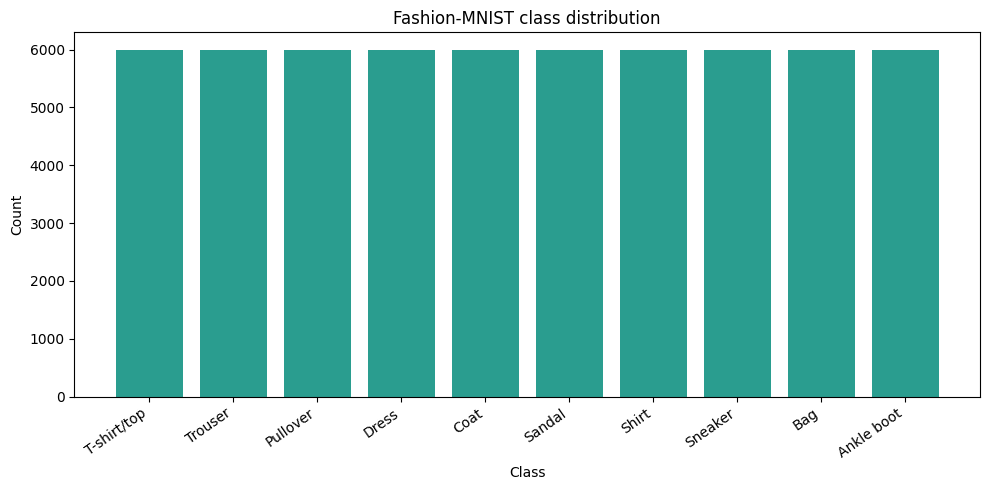

In [4]:
plt.figure(figsize=(10, 5))
plt.bar(class_df["class_name"], class_df["count"], color="#2a9d8f")
plt.title("Fashion-MNIST class distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=160)
plt.show()

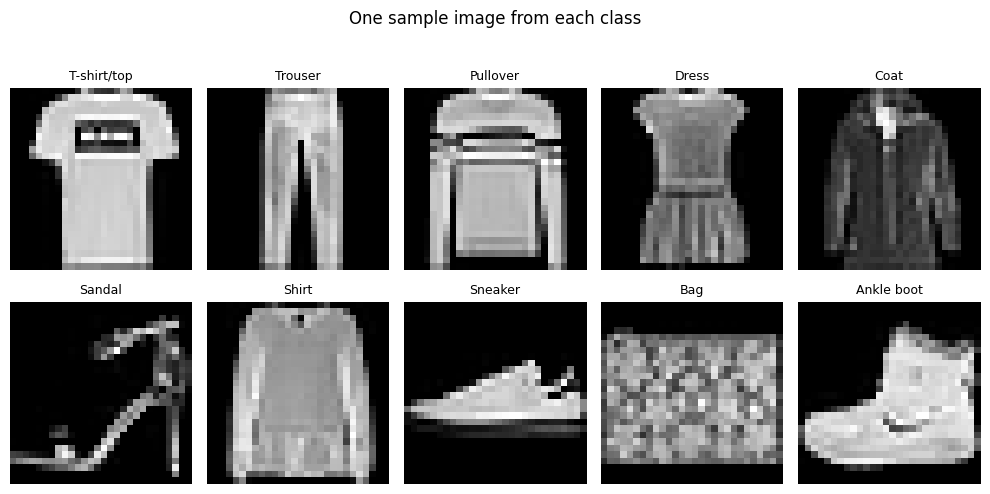

In [5]:
plt.figure(figsize=(10, 5))
for class_id, class_name in enumerate(CLASS_NAMES):
    idx = np.where(y_train == class_id)[0][0]
    plt.subplot(2, 5, class_id + 1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.title(class_name, fontsize=9)
    plt.axis("off")
plt.suptitle("One sample image from each class", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_images.png", dpi=160)
plt.show()

,metric,value
0,min,0.000000
1,max,255.000000
2,mean,72.940352
3,std,90.021182


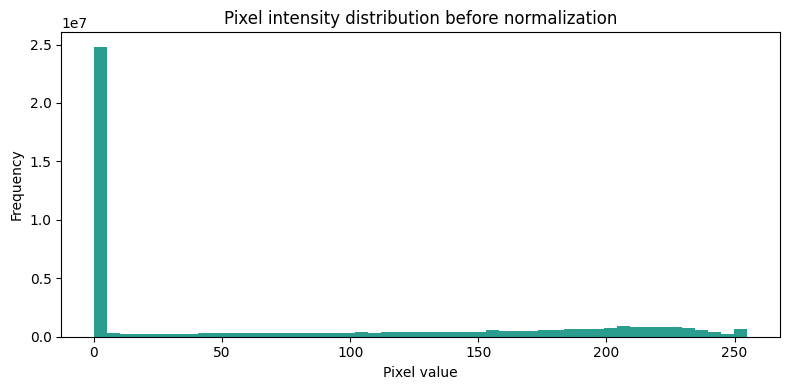

In [6]:
pixel_stats = pd.DataFrame(
    {
        "metric": ["min", "max", "mean", "std"],
        "value": [x_train.min(), x_train.max(), x_train.mean(), x_train.std()],
    }
)
display(pixel_stats)

plt.figure(figsize=(8, 4))
plt.hist(x_train.flatten(), bins=50, color="#2a9d8f")
plt.title("Pixel intensity distribution before normalization")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pixel_distribution.png", dpi=160)
plt.show()

## 3. Preprocessing

Алдын ала өңдеу қадамдары:

- pixel мәндерін `0..255` аралығынан `0..1` аралығына normalization жасау;
- training set ішінен validation set бөлу;
- MLP үшін суреттерді 784 өлшемді vector-ға айналдыру;
- CNN үшін channel dimension қосу: `(28, 28, 1)`.

In [7]:
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

x_train_part, x_val_part, y_train_part, y_val_part = stratified_train_val_split(
    x_train_norm,
    y_train,
    test_size=0.1,
    seed=42,
)

x_train_mlp = x_train_part.reshape(-1, 28 * 28)
x_val_mlp = x_val_part.reshape(-1, 28 * 28)
x_test_mlp = x_test_norm.reshape(-1, 28 * 28)

x_train_cnn = x_train_part[..., np.newaxis]
x_val_cnn = x_val_part[..., np.newaxis]
x_test_cnn = x_test_norm[..., np.newaxis]

print("MLP train shape:", x_train_mlp.shape)
print("CNN train shape:", x_train_cnn.shape)
print("Validation labels:", y_val_part.shape)

MLP train shape: (54000, 784)
CNN train shape: (54000, 28, 28, 1)
Validation labels: (6000,)


## 4. Model 1: MLP neural network

In [8]:
def build_mlp_model():
    model = keras.Sequential(
        [
            layers.Input(shape=(784,)),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.30),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.20),
            layers.Dense(10, activation="softmax"),
        ],
        name="mlp_model",
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

mlp_model = build_mlp_model()
mlp_model.summary()

Model: "mlp_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Model 2: CNN neural network

In [9]:
def build_cnn_model():
    model = keras.Sequential(
        [
            layers.Input(shape=(28, 28, 1)),
            layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
            layers.MaxPooling2D(pool_size=2),
            layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
            layers.MaxPooling2D(pool_size=2),
            layers.Flatten(),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.30),
            layers.Dense(10, activation="softmax"),
        ],
        name="cnn_model",
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

cnn_model = build_cnn_model()
cnn_model.summary()

Model: "cnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Модельдерді оқыту

In [10]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=2,
    restore_best_weights=True,
)

history_mlp = mlp_model.fit(
    x_train_mlp,
    y_train_part,
    validation_data=(x_val_mlp, y_val_part),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/3


  1/422 ━━━━━━━━━━━━━━━━━━━━ 5:37 802ms/step - accuracy: 0.1094 - loss: 2.4548

 17/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3205 - loss: 1.9422    

 33/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4128 - loss: 1.6795

 48/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4635 - loss: 1.5311

...

379/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8559 - loss: 0.4069

393/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8560 - loss: 0.4063

406/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8562 - loss: 0.4057

421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8563 - loss: 0.4051

422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8605 - loss: 0.3888 - val_accuracy: 0.8657 - val_loss: 0.3618


In [11]:
history_cnn = cnn_model.fit(
    x_train_cnn,
    y_train_part,
    validation_data=(x_val_cnn, y_val_part),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/3


  1/422 ━━━━━━━━━━━━━━━━━━━━ 5:41 812ms/step - accuracy: 0.1172 - loss: 2.2954

  4/422 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.1803 - loss: 2.2243   

  7/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.2145 - loss: 2.1568

 10/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.2452 - loss: 2.0810

...

412/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8892 - loss: 0.3063

415/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8893 - loss: 0.3062

418/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8893 - loss: 0.3061

421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8894 - loss: 0.3060

422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8948 - loss: 0.2913 - val_accuracy: 0.8898 - val_loss: 0.2884


## 7. Модель сапасын бағалау және салыстыру

In [12]:
def evaluate_model(model, x_test_model, model_name):
    test_loss, test_accuracy = model.evaluate(x_test_model, y_test, verbose=0)
    y_pred = np.argmax(model.predict(x_test_model, verbose=0), axis=1)

    report_df = make_classification_report(y_test, y_pred)
    report_df.to_csv(RESULTS_DIR / f"{model_name}_classification_report.csv")

    model.save(MODELS_DIR / f"{model_name}.keras")

    return {
        "model": model_name,
        "test_loss": float(test_loss),
        "test_accuracy": float(test_accuracy),
        "parameters": int(model.count_params()),
    }, report_df, y_pred


mlp_metrics, mlp_report, y_pred_mlp = evaluate_model(mlp_model, x_test_mlp, "mlp")
cnn_metrics, cnn_report, y_pred_cnn = evaluate_model(cnn_model, x_test_cnn, "cnn")

comparison_df = pd.DataFrame([mlp_metrics, cnn_metrics]).sort_values(
    "test_accuracy", ascending=False
)
comparison_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)

with open(RESULTS_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump([mlp_metrics, cnn_metrics], f, indent=2)

comparison_df

,model,test_loss,test_accuracy,parameters
1,cnn,0.299806,0.8925,421642
0,mlp,0.380523,0.8629,235146


In [13]:
print("MLP classification report")
display(mlp_report.round(3))

print("CNN classification report")
display(cnn_report.round(3))

MLP classification report


,precision,recall,f1-score,support
class,,,,
T-shirt/top,0.793,0.851,0.821,1000.0
Trouser,0.985,0.962,0.973,1000.0
Pullover,0.806,0.707,0.753,1000.0
Dress,0.857,0.884,0.870,1000.0
Coat,0.691,0.870,0.770,1000.0
Sandal,0.983,0.917,0.949,1000.0
Shirt,0.748,0.548,0.632,1000.0
Sneaker,0.906,0.950,0.927,1000.0
Bag,0.939,0.980,0.959,1000.0


CNN classification report


,precision,recall,f1-score,support
class,,,,
T-shirt/top,0.779,0.904,0.837,1000.0
Trouser,0.985,0.980,0.982,1000.0
Pullover,0.825,0.843,0.834,1000.0
Dress,0.880,0.928,0.903,1000.0
Coat,0.785,0.865,0.823,1000.0
Sandal,0.993,0.950,0.971,1000.0
Shirt,0.842,0.540,0.658,1000.0
Sneaker,0.931,0.965,0.947,1000.0
Bag,0.966,0.982,0.974,1000.0


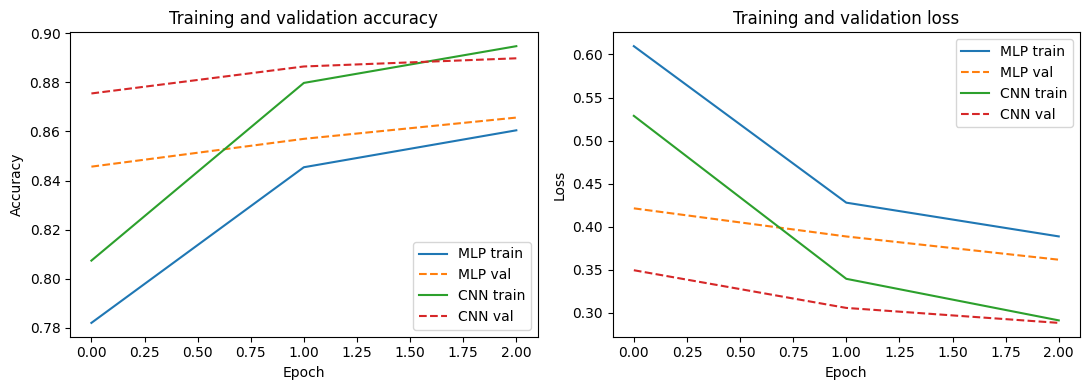

In [14]:
histories = {"MLP": history_mlp, "CNN": history_cnn}

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
for name, history in histories.items():
    plt.plot(history.history["accuracy"], label=f"{name} train")
    plt.plot(history.history["val_accuracy"], linestyle="--", label=f"{name} val")
plt.title("Training and validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
for name, history in histories.items():
    plt.plot(history.history["loss"], label=f"{name} train")
    plt.plot(history.history["val_loss"], linestyle="--", label=f"{name} val")
plt.title("Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_history.png", dpi=160)
plt.show()

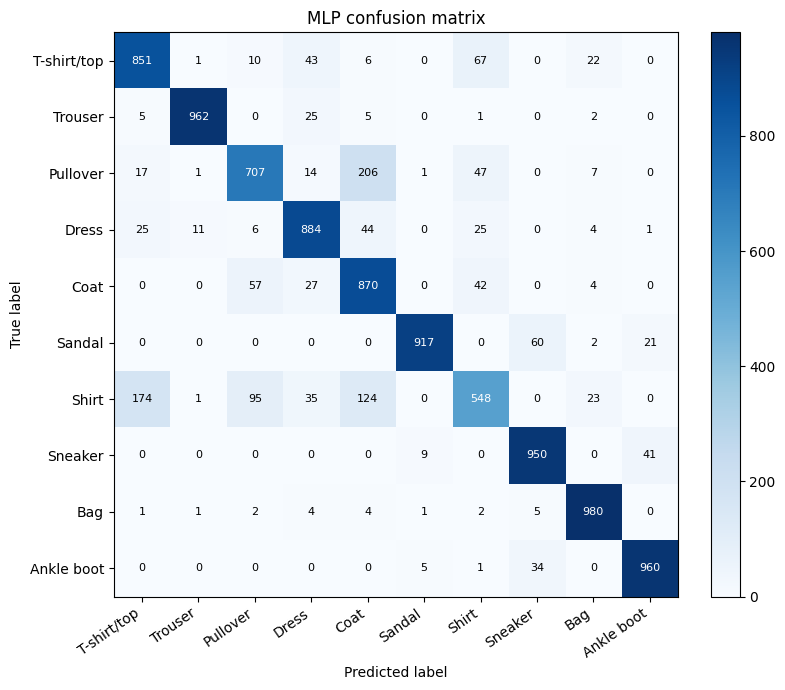

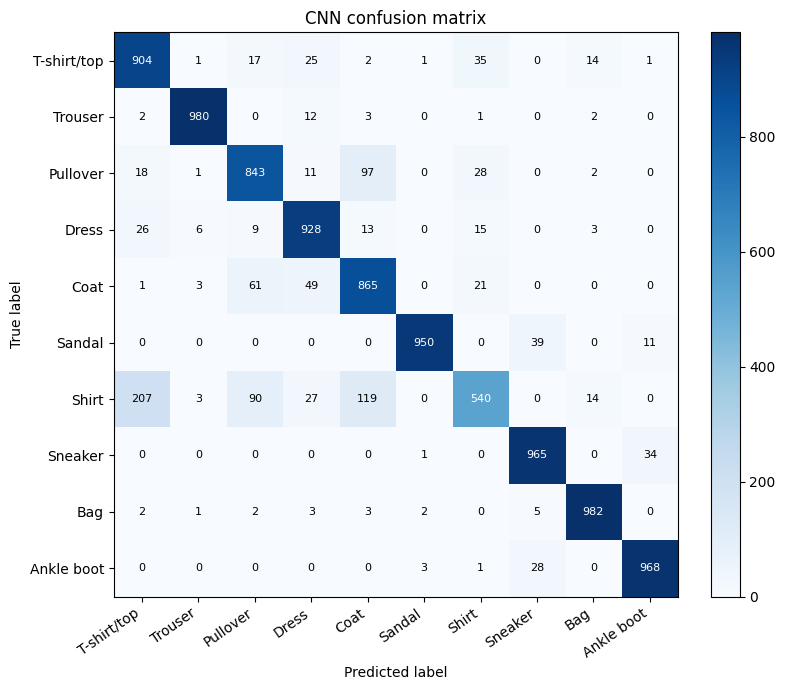

In [15]:
def show_confusion_matrix(y_true, y_pred, title, filename):
    matrix = make_confusion_matrix(y_true, y_pred, len(CLASS_NAMES))
    plt.figure(figsize=(9, 7))
    plt.imshow(matrix, interpolation="nearest", cmap="Blues")
    plt.colorbar(fraction=0.046, pad=0.04)
    tick_marks = np.arange(len(CLASS_NAMES))
    plt.xticks(tick_marks, CLASS_NAMES, rotation=35, ha="right")
    plt.yticks(tick_marks, CLASS_NAMES)
    threshold = matrix.max() / 2
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            color = "white" if matrix[row, col] > threshold else "black"
            plt.text(col, row, str(matrix[row, col]), ha="center", va="center", color=color, fontsize=8)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=160)
    plt.show()


show_confusion_matrix(y_test, y_pred_mlp, "MLP confusion matrix", "mlp_confusion_matrix.png")
show_confusion_matrix(y_test, y_pred_cnn, "CNN confusion matrix", "cnn_confusion_matrix.png")

## 8. Қорытынды

Бұл project Fashion-MNIST dataset арқылы image classification міндетін шешеді. MLP моделі базалық neural network ретінде алынды, ал CNN моделі суреттегі локалды pattern-дерді convolution қабаттары арқылы үйренеді.

Күтілетін нәтиже бойынша CNN accuracy көрсеткіші MLP-ден жоғары болады, себебі CNN суреттің кеңістіктік құрылымын сақтап өңдейді. MLP болса, суретті бір ұзын vector ретінде қарайды.

**Жоба нәтижелері сақталған орындар:**

- `figures/` - EDA және model evaluation графиктері;
- `results/` - metrics және classification reports;
- `models/` - оқытылған Keras модельдері.